In [2]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
import os
import warnings

import sys
sys.path.append("../")

In [3]:
def agregar_resultados(df):
    colunas_numericas = ["acc", "prec", "rec", "f1", "emissions_g", "energia_kwh", "tempo_s", "emissions_grid_total_g", "energia_grid_total_kwh"]
    
    for col in colunas_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        
    df_agregado = (
        df.groupby("modelo")
        .agg(
            acc_media=("acc", "mean"),
            acc_desvio=("acc", "std"),
            prec_media=("prec", "mean"),
            prec_desvio=("prec", "std"),
            rec_media=("rec", "mean"),
            rec_desvio=("rec", "std"),
            f1_media=("f1", "mean"),
            f1_desvio=("f1", "std"),
            emissions_g_total=("emissions_g", "sum"),
            energia_kwh_total=("energia_kwh", "sum"),
            tempo_s_total=("tempo_s", "sum"),
            emissions_grid_total_g_soma=("emissions_grid_total_g", "sum"),
            energia_grid_total_kwh_soma=("energia_grid_total_kwh", "sum"),
        )
        .reset_index()
    )

    df_agregado["emissoes_total_modelo"] = df_agregado["emissions_g_total"] + df_agregado["emissions_grid_total_g_soma"]
    df_agregado["energia_total_modelo"] = df_agregado["energia_kwh_total"] + df_agregado["energia_grid_total_kwh_soma"]
    
    df_agregado["ECAR"] = (df_agregado["energia_total_modelo"] * 46.1)/ df_agregado["f1_media"]

    return df_agregado

In [4]:
for i in range(0, 51, 10):
    print(f"Processando cenário: {i}%")

    arquivo = pd.read_csv(f'../reports/resultados/German/[REDUCAO {i}% - CC]-German.csv', sep=';')
    
    arquivo['reducao'] = f"0%" if i == 0 else f"-{i}%"

    reducao_agregada = agregar_resultados(arquivo)
    reducao_agregada['reducao'] = f"0%" if i == 0 else f"-{i}%"

    reducao_agregada.to_csv(f'../reports/resultados_artigo/German/[REDUCAO {i}% - CC].csv', sep=';', index=False)

    if i != 0:
        arquivo = pd.read_csv(f'../reports/resultados/German/[AUMENTO {i}% - CC]-German.csv', sep=';')

        arquivo['aumento'] = f"+{i}%"

        aumento_agregado = agregar_resultados(arquivo)
        aumento_agregado['aumento'] = f"+{i}%"

        aumento_agregado.to_csv(f'../reports/resultados_artigo/German/[AUMENTO {i}% - CC].csv', sep=';', index=False)

    arquivo_bondora = pd.read_csv(f'../reports/resultados/Bondora/[REDUCAO {i}% - CC]-Bondora.csv', sep=';')
    arquivo_bondora['reducao'] = f"0%" if i == 0 else f"-{i}%"

    reducao_agregada_bondora = agregar_resultados(arquivo_bondora)
    reducao_agregada_bondora['reducao'] = f"0%" if i == 0 else f"-{i}%"

    reducao_agregada_bondora.to_csv(f'../reports/resultados_artigo/Bondora/[REDUCAO {i}% - CC].csv', sep=';', index=False)

    if i != 0:
        arquivo_bondora = pd.read_csv(f'../reports/resultados/Bondora/[AUMENTO {i}% - CC]-Bondora.csv', sep=';')

        arquivo_bondora['aumento'] = f"+{i}%"

        aumento_agregado_bondora = agregar_resultados(arquivo_bondora)
        aumento_agregado_bondora['aumento'] = f"+{i}%"

        aumento_agregado_bondora.to_csv(f'../reports/resultados_artigo/Bondora/[AUMENTO {i}% - CC].csv', sep=';', index=False)

Processando cenário: 0%
Processando cenário: 10%
Processando cenário: 20%
Processando cenário: 30%
Processando cenário: 40%
Processando cenário: 50%


In [5]:
import pandas as pd
import os

def imprimir_linhas_latex_baseline(caminho_arquivo):
    if not os.path.exists(caminho_arquivo):
        print(f"    % [AVISO] Arquivo não encontrado: {caminho_arquivo}")
        return
        
    df = pd.read_csv(caminho_arquivo, sep=';')
    
    df = df.sort_values('modelo')
    
    for _, row in df.iterrows():
        modelo = row['modelo']
        
        acc = f"${row['acc_media']:.4f} \\pm {row['acc_desvio']:.4f}$"
        prec = f"${row['prec_media']:.4f} \\pm {row['prec_desvio']:.4f}$"
        rec = f"${row['rec_media']:.4f} \\pm {row['rec_desvio']:.4f}$"
        f1 = f"${row['f1_media']:.4f} \\pm {row['f1_desvio']:.4f}$"
        
        tempo = f"${row['tempo_s_total']:.2f}$" 
        emissoes = f"${row['emissoes_total_modelo']:.4f}$"
        energia = f"${row['energia_total_modelo']:.4f}$"
        ecar = f"${row['ECAR']:.4f}$"
        
        linha_latex = f"     & {modelo:<8} & {acc} & {prec} & {rec} & {f1} & {tempo} & {emissoes} & {energia} & {ecar} \\\\"
        print(linha_latex)

print("Copiando as linhas para o LaTeX...\n")

print("    % --- PRIMEIRA BASE DE DADOS ---")
print("    \\multirow{6}{*}{\\textbf{Bondora}} ")
                         
imprimir_linhas_latex_baseline("../reports/resultados_artigo/Bondora/[REDUCAO 0% - CC].csv")

print("    \\midrule")
print("    ")
print("    % --- SEGUNDA BASE DE DADOS ---")
print("    \\multirow{6}{*}{\\textbf{German Credit}} ")
                                                                         
imprimir_linhas_latex_baseline("../reports/resultados_artigo/German/[REDUCAO 0% - CC].csv") 


Copiando as linhas para o LaTeX...

    % --- PRIMEIRA BASE DE DADOS ---
    \multirow{6}{*}{\textbf{Bondora}} 
     & KNN      & $0.6822 \pm 0.0032$ & $0.6892 \pm 0.0045$ & $0.7962 \pm 0.0050$ & $0.7388 \pm 0.0029$ & $152.63$ & $5.1147$ & $0.0529$ & $3.3012$ \\
     & LR       & $0.6833 \pm 0.0043$ & $0.6869 \pm 0.0043$ & $0.8067 \pm 0.0049$ & $0.7420 \pm 0.0040$ & $32.66$ & $0.4683$ & $0.0048$ & $0.2980$ \\
     & LightGBM & $0.7163 \pm 0.0038$ & $0.7081 \pm 0.0045$ & $0.8464 \pm 0.0043$ & $0.7711 \pm 0.0025$ & $15.38$ & $0.6228$ & $0.0063$ & $0.3786$ \\
     & MLP      & $0.6981 \pm 0.0039$ & $0.7025 \pm 0.0062$ & $0.8072 \pm 0.0205$ & $0.7511 \pm 0.0069$ & $663.76$ & $29.5034$ & $0.3019$ & $18.5309$ \\
     & RF       & $0.7215 \pm 0.0038$ & $0.7129 \pm 0.0051$ & $0.8484 \pm 0.0028$ & $0.7748 \pm 0.0030$ & $125.85$ & $1.1057$ & $0.0113$ & $0.6735$ \\
     & XGBoost  & $0.7135 \pm 0.0122$ & $0.7031 \pm 0.0207$ & $0.8558 \pm 0.0279$ & $0.7713 \pm 0.0036$ & $41.67$ & $2.4162$ & $0.024

Gráfico gerado com sucesso em: ../reports/graficos/f1_barras_ecar_linhas_6modelos.pdf


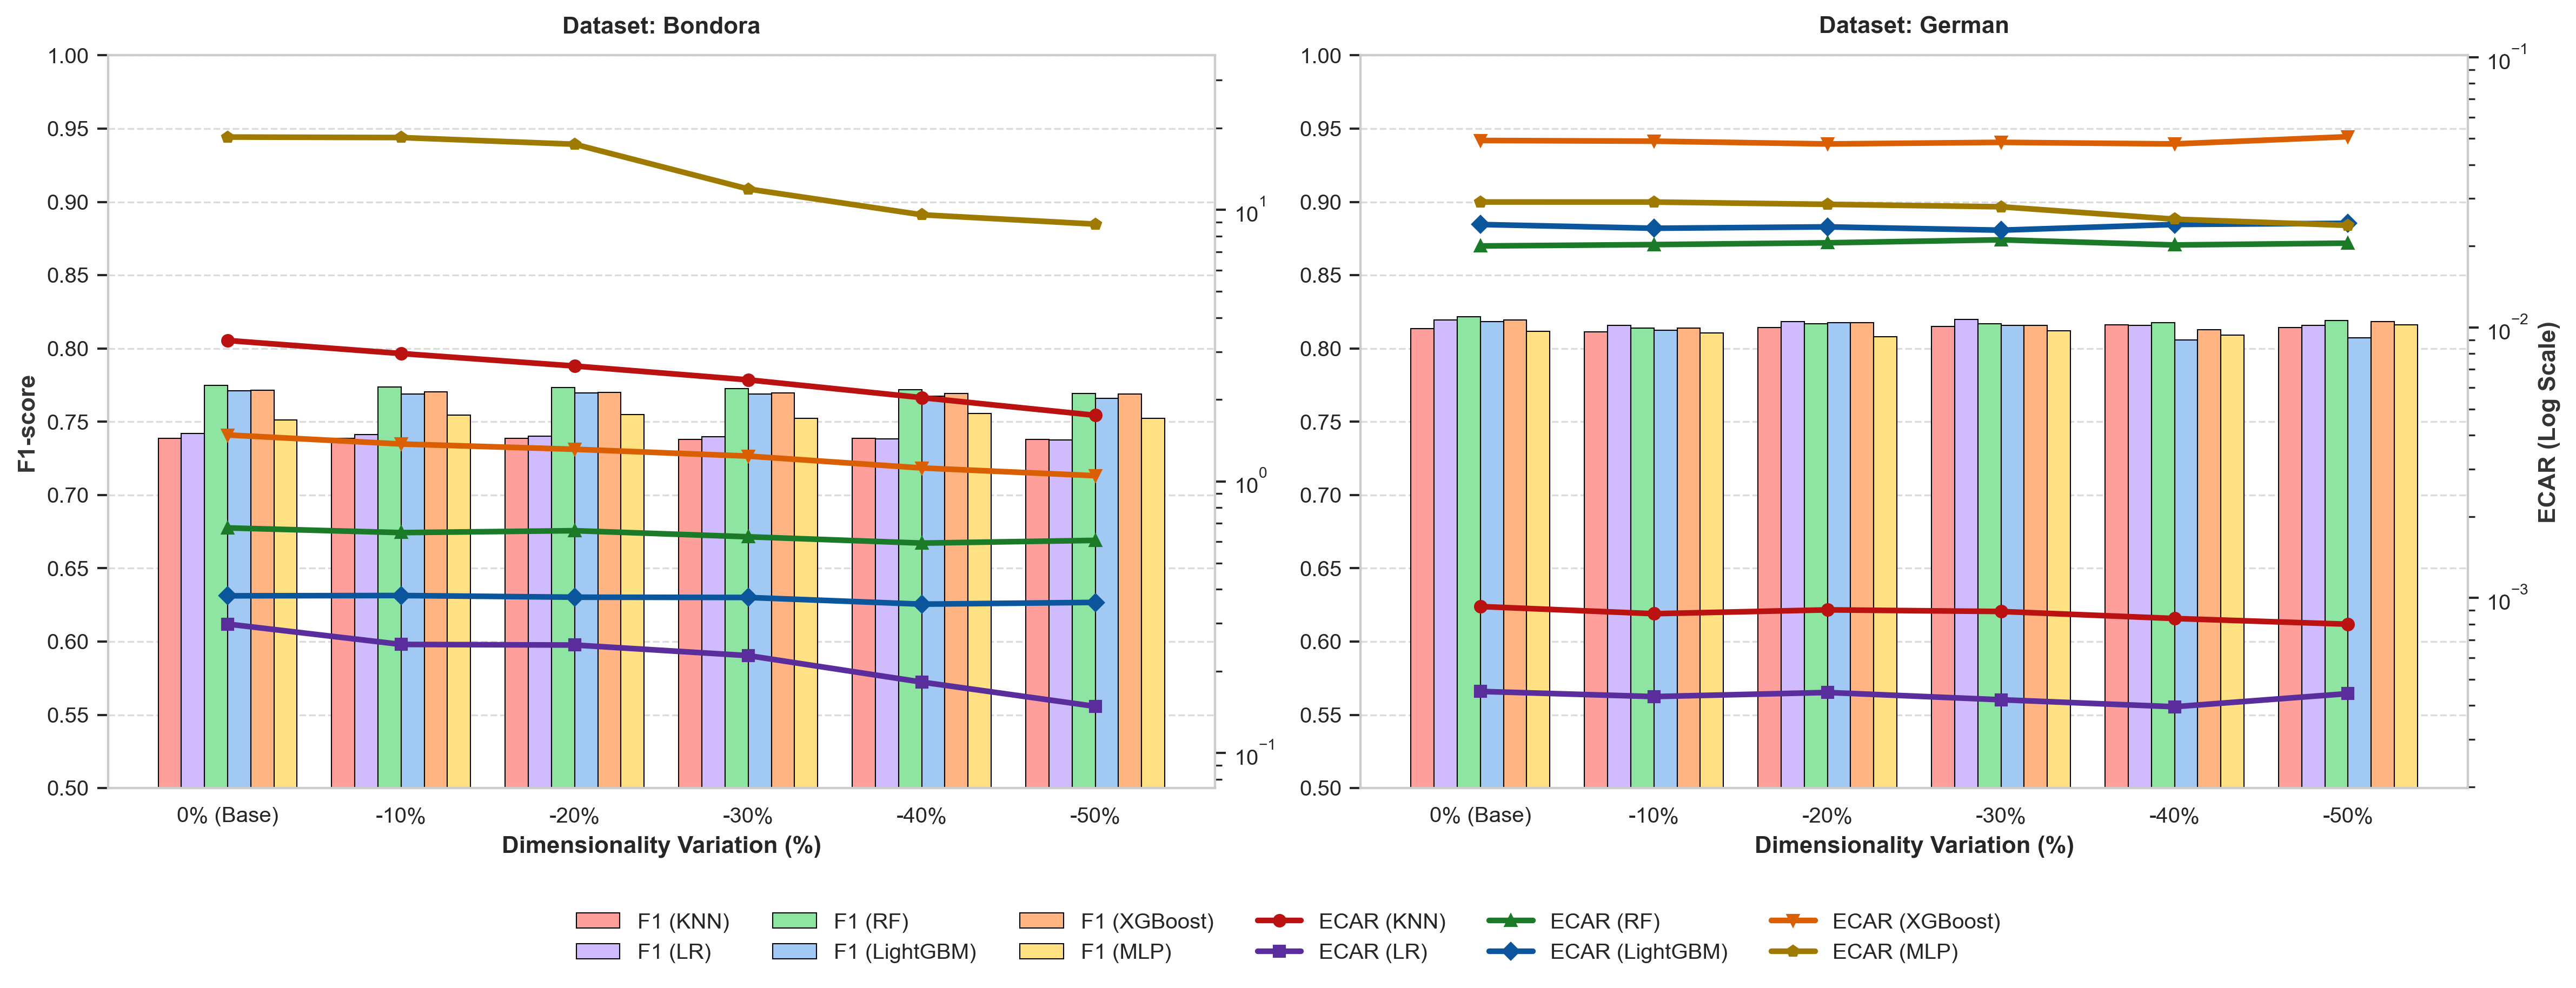

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

bases = ['Bondora', 'German']
modelos = ['KNN', 'LR', 'RF', 'LightGBM', 'XGBoost', 'MLP']
cenarios = [0, -10, -20, -30, -40, -50]

dados_consolidados = []
for base in bases:
    for cenario in cenarios:
        percentual = abs(cenario)
        caminho = f'../reports/resultados_artigo/{base}/[REDUCAO {percentual}% - CC].csv'
        
        if os.path.exists(caminho):
            df_agregado = pd.read_csv(caminho, sep=';')
            for _, row in df_agregado.iterrows():
                if row['modelo'] in modelos:
                    dados_consolidados.append({
                        'Dataset': base, 
                        'Model': row['modelo'], 
                        'Dimensionality': cenario,
                        'F1_score': row['f1_media'], 
                        'ECAR': row['ECAR']
                    })

df = pd.DataFrame(dados_consolidados)

if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

    cores_barras = {
        'LightGBM': '#a1c9f4', 'XGBoost': '#ffb482', 'RF': '#8de5a1', 
        'KNN': '#ff9f9b', 'LR': '#d0bbff', 'MLP': '#ffe082'
    } 
    cores_linhas = {
        'LightGBM': '#0a559c', 'XGBoost': '#d95f02', 'RF': '#1a7a27', 
        'KNN': '#ba1111', 'LR': '#5a2d9c', 'MLP': '#9e7b00'
    }
    marcadores = {
        'KNN': 'o', 'LR': 's', 'RF': '^', 'LightGBM': 'D', 'XGBoost': 'v', 'MLP': 'p'
    }

    handles_bar_dict = {}
    handles_line_dict = {}

    for i, base in enumerate(bases):
        ax1 = axes[i]
        df_base = df[df['Dataset'] == base]
        
        if df_base.empty:
            continue
            
        x = np.arange(len(cenarios))
        total_width = 0.8
        width = total_width / len(modelos)
        offsets = np.linspace(-total_width/2 + width/2, total_width/2 - width/2, len(modelos))
        
        ax1.set_xlabel('Dimensionality Variation (%)', fontweight='bold')
        if i == 0:
            ax1.set_ylabel('F1-score', fontweight='bold', color='#333333')
            
        ax2 = ax1.twinx()
        if i == 1:
            ax2.set_ylabel('ECAR (Log Scale)', fontweight='bold', color='#333333')
        
        ax2.set_yscale('log')
        
        for idx, modelo in enumerate(modelos):
            dados_modelo = df_base[df_base['Model'] == modelo].sort_values('Dimensionality', ascending=False)
            if not dados_modelo.empty:
                # Plota as barras de F1
                b = ax1.bar(x + offsets[idx], dados_modelo['F1_score'], width, 
                            color=cores_barras[modelo], edgecolor='black', linewidth=0.5)
                
                # Plota as linhas de ECAR
                l = ax2.plot(x, dados_modelo['ECAR'], marker=marcadores[modelo], 
                             color=cores_linhas[modelo], linewidth=2.5, markersize=5)
                             
                if i == 0:
                    handles_bar_dict[modelo] = b[0]
                    handles_line_dict[modelo] = l[0]
        
        ax1.set_ylim(0.5, 1.0)
        ax1.set_yticks(np.arange(0.5, 1.05, 0.05))
        ax1.set_xticks(x)
        ax1.set_xticklabels([f"{c}%" if c != 0 else "0% (Base)" for c in cenarios])
        ax1.grid(axis='y', linestyle='--', alpha=0.7) 
        ax1.grid(axis='x', visible=False)
        
        min_ecar = df_base['ECAR'].min() * 0.5
        max_ecar = df_base['ECAR'].max() * 2.0
        ax2.set_ylim(min_ecar, max_ecar)
        ax2.grid(False)
        
        nome_base_bonito = base.replace('_', ' ')
        ax1.set_title(f'Dataset: {nome_base_bonito}', fontweight='bold', pad=10)

    # Organizando a legenda para o Matplotlib preencher nas colunas certas
    model_top = ['KNN', 'RF', 'XGBoost']
    model_bot = ['LR', 'LightGBM', 'MLP']

    ordered_handles = []
    ordered_labels = []

    # Intercalando Top e Bot para as primeiras 3 colunas (F1)
    for t, b in zip(model_top, model_bot):
        ordered_handles.append(handles_bar_dict[t])
        ordered_labels.append(f"F1 ({t})")
        ordered_handles.append(handles_bar_dict[b])
        ordered_labels.append(f"F1 ({b})")

    # Intercalando Top e Bot para as últimas 3 colunas (ECAR)
    for t, b in zip(model_top, model_bot):
        ordered_handles.append(handles_line_dict[t])
        ordered_labels.append(f"ECAR ({t})")
        ordered_handles.append(handles_line_dict[b])
        ordered_labels.append(f"ECAR ({b})")

    # Cria a legenda unificada e compacta
    fig.legend(ordered_handles, ordered_labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=6, frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18) 
    caminho_salvar = '../reports/graficos/f1_barras_ecar_linhas_6modelos.pdf'
    plt.savefig(caminho_salvar, format='pdf', bbox_inches='tight')
    print(f"Gráfico gerado com sucesso em: {caminho_salvar}")


Gráfico de AUMENTO gerado com sucesso em: ../reports/graficos/f1_barras_ecar_linhas_6modelos_aumento.pdf


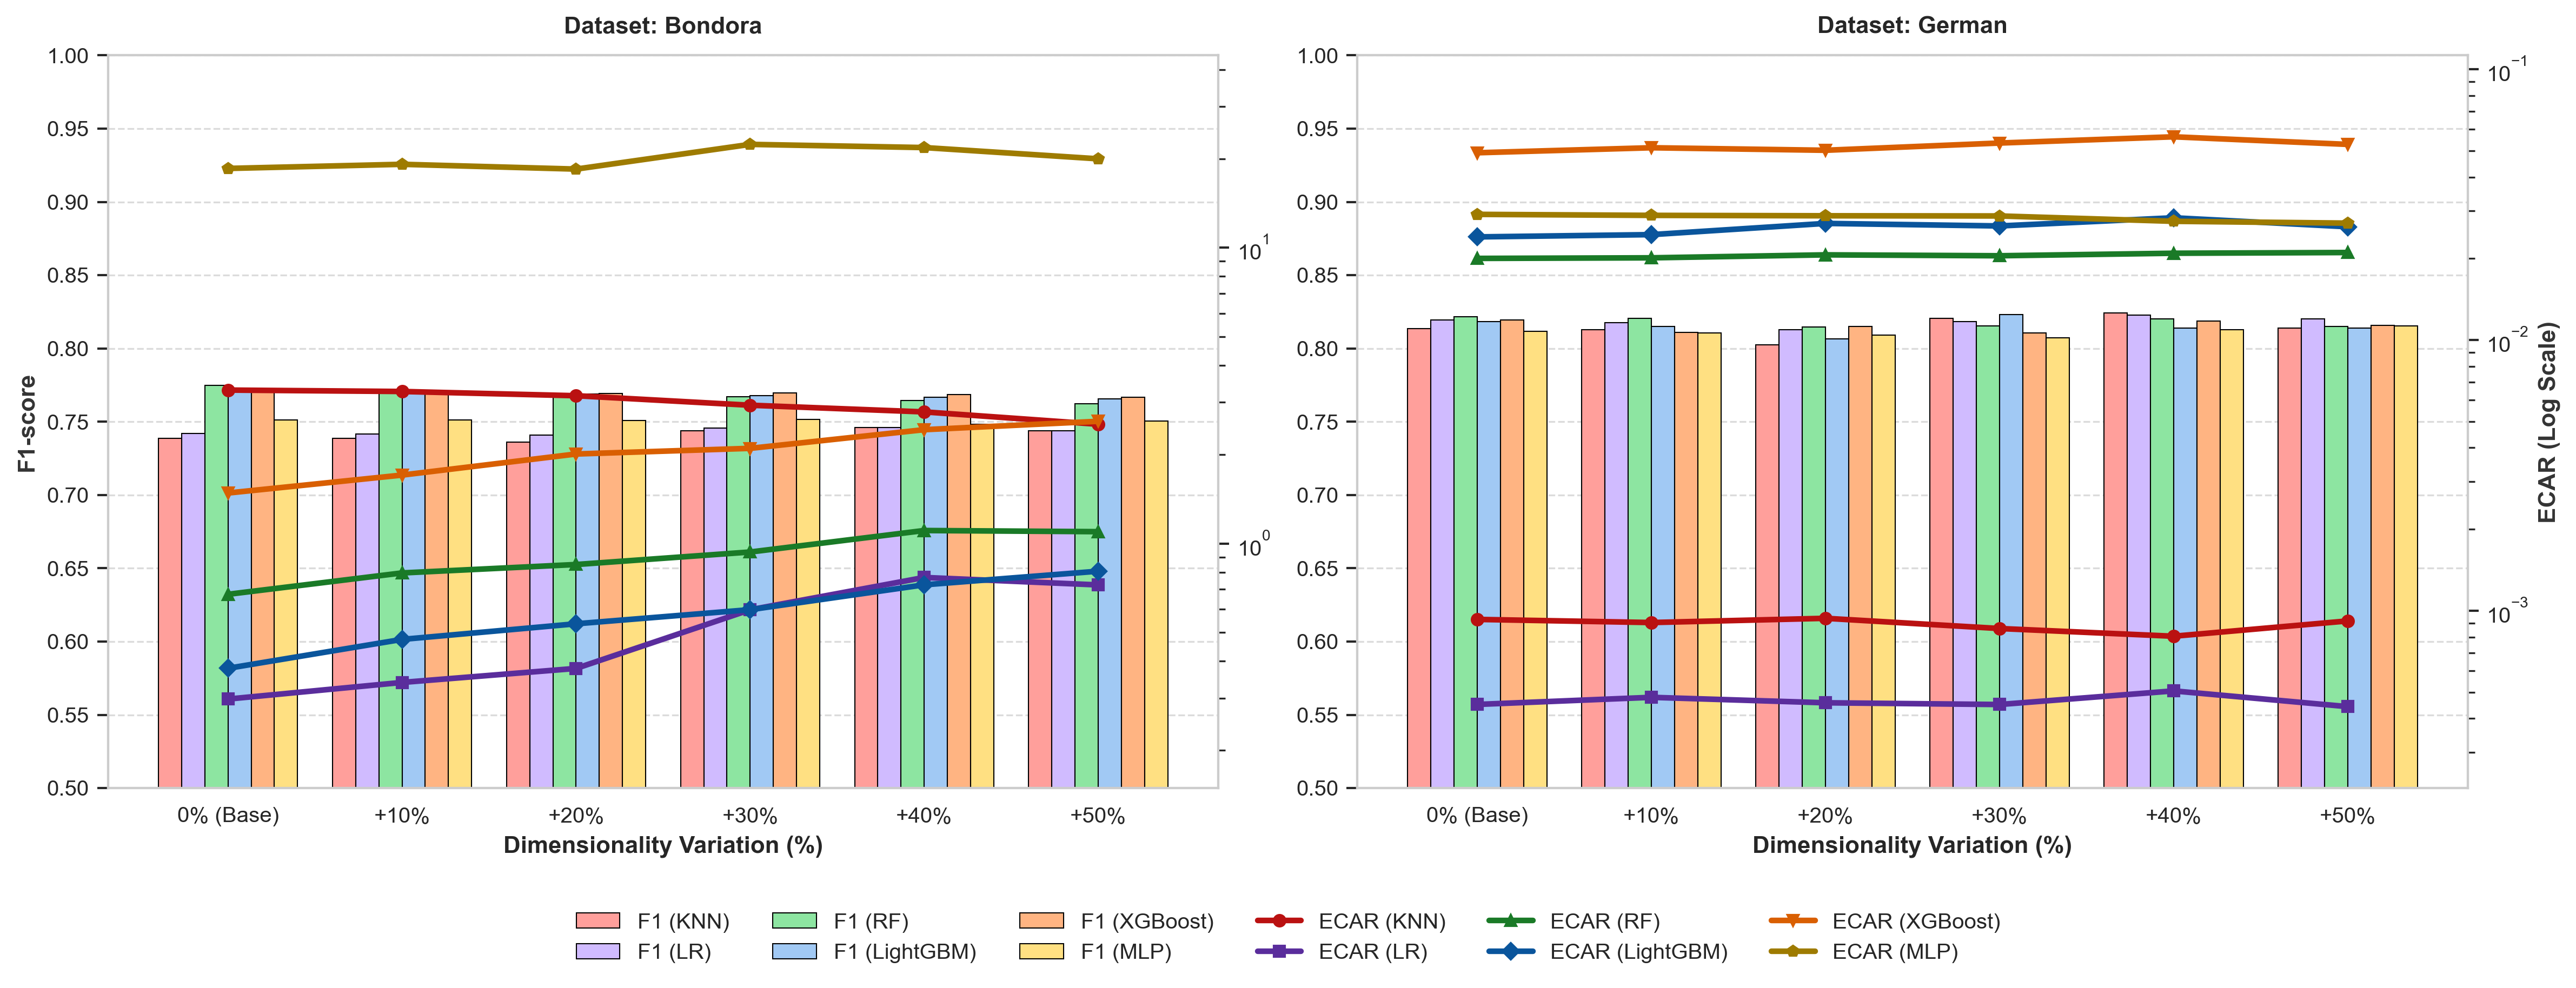

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

bases = ['Bondora', 'German']
modelos = ['KNN', 'LR', 'RF', 'LightGBM', 'XGBoost', 'MLP']
# Cenários positivos para Aumento
cenarios = [0, 10, 20, 30, 40, 50]

dados_consolidados = []
for base in bases:
    for cenario in cenarios:
        # A base (0%) sempre vem do arquivo de redução 0%
        if cenario == 0:
            caminho = f'../reports/resultados_artigo/{base}/[REDUCAO 0% - CC].csv'
        else:
            caminho = f'../reports/resultados_artigo/{base}/[AUMENTO {cenario}% - CC].csv'
        
        if os.path.exists(caminho):
            df_agregado = pd.read_csv(caminho, sep=';')
            for _, row in df_agregado.iterrows():
                if row['modelo'] in modelos:
                    dados_consolidados.append({
                        'Dataset': base, 
                        'Model': row['modelo'], 
                        'Dimensionality': cenario,
                        'F1_score': row['f1_media'], 
                        'ECAR': row['ECAR']
                    })

df = pd.DataFrame(dados_consolidados)

if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

    # Mantendo rigorosamente as mesmas cores
    cores_barras = {
        'LightGBM': '#a1c9f4', 'XGBoost': '#ffb482', 'RF': '#8de5a1', 
        'KNN': '#ff9f9b', 'LR': '#d0bbff', 'MLP': '#ffe082'
    } 
    cores_linhas = {
        'LightGBM': '#0a559c', 'XGBoost': '#d95f02', 'RF': '#1a7a27', 
        'KNN': '#ba1111', 'LR': '#5a2d9c', 'MLP': '#9e7b00'
    }
    marcadores = {
        'KNN': 'o', 'LR': 's', 'RF': '^', 'LightGBM': 'D', 'XGBoost': 'v', 'MLP': 'p'
    }

    handles_bar_dict = {}
    handles_line_dict = {}

    for i, base in enumerate(bases):
        ax1 = axes[i]
        df_base = df[df['Dataset'] == base]
        
        if df_base.empty:
            continue
            
        x = np.arange(len(cenarios))
        total_width = 0.8
        width = total_width / len(modelos)
        offsets = np.linspace(-total_width/2 + width/2, total_width/2 - width/2, len(modelos))
        
        ax1.set_xlabel('Dimensionality Variation (%)', fontweight='bold')
        if i == 0:
            ax1.set_ylabel('F1-score', fontweight='bold', color='#333333')
            
        ax2 = ax1.twinx()
        if i == 1:
            ax2.set_ylabel('ECAR (Log Scale)', fontweight='bold', color='#333333')
        
        ax2.set_yscale('log')
        
        for idx, modelo in enumerate(modelos):
            # Garante que a ordem dos dados vai bater com a ordem do eixo X (0 a 50)
            dados_modelo = df_base[df_base['Model'] == modelo].set_index('Dimensionality').reindex(cenarios).reset_index()
            
            if not dados_modelo['F1_score'].isna().all():
                # Plota as barras de F1
                b = ax1.bar(x + offsets[idx], dados_modelo['F1_score'], width, 
                            color=cores_barras[modelo], edgecolor='black', linewidth=0.5)
                
                # Plota as linhas de ECAR
                l = ax2.plot(x, dados_modelo['ECAR'], marker=marcadores[modelo], 
                             color=cores_linhas[modelo], linewidth=2.5, markersize=5)
                             
                if i == 0:
                    handles_bar_dict[modelo] = b[0]
                    handles_line_dict[modelo] = l[0]
        
        ax1.set_ylim(0.5, 1.0)
        ax1.set_yticks(np.arange(0.5, 1.05, 0.05))
        ax1.set_xticks(x)
        # Ticks positivos
        ax1.set_xticklabels([f"+{c}%" if c != 0 else "0% (Base)" for c in cenarios])
        ax1.grid(axis='y', linestyle='--', alpha=0.7) 
        ax1.grid(axis='x', visible=False)
        
        min_ecar = df_base['ECAR'].min() * 0.5
        max_ecar = df_base['ECAR'].max() * 2.0
        ax2.set_ylim(min_ecar, max_ecar)
        ax2.grid(False)
        
        nome_base_bonito = base.replace('_', ' ')
        ax1.set_title(f'Dataset: {nome_base_bonito}', fontweight='bold', pad=10)

    # Organizando a legenda como você pediu
    model_top = ['KNN', 'RF', 'XGBoost']
    model_bot = ['LR', 'LightGBM', 'MLP']

    ordered_handles = []
    ordered_labels = []

    for t, b in zip(model_top, model_bot):
        ordered_handles.append(handles_bar_dict[t])
        ordered_labels.append(f"F1 ({t})")
        ordered_handles.append(handles_bar_dict[b])
        ordered_labels.append(f"F1 ({b})")

    for t, b in zip(model_top, model_bot):
        ordered_handles.append(handles_line_dict[t])
        ordered_labels.append(f"ECAR ({t})")
        ordered_handles.append(handles_line_dict[b])
        ordered_labels.append(f"ECAR ({b})")

    fig.legend(ordered_handles, ordered_labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=6, frameon=False)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.18) 
    
    # Salva com outro nome para separar do gráfico de redução
    caminho_salvar = '../reports/graficos/f1_barras_ecar_linhas_6modelos_aumento.pdf'
    plt.savefig(caminho_salvar, format='pdf', bbox_inches='tight')
    print(f"Gráfico de AUMENTO gerado com sucesso em: {caminho_salvar}")


In [25]:
import pandas as pd
import os

bases = ['Bondora', 'German']
total_energy = 0.0
arquivos_processados = 0

print("=== SOMANDO CUSTO AMBIENTAL DE TODOS OS EXPERIMENTOS ===")

for base in bases:
    caminho_base = f'../reports/resultados_artigo/{base}/'
    
    for arquivo in os.listdir(caminho_base):
        if arquivo.endswith(".csv"):
            df = pd.read_csv(os.path.join(caminho_base, arquivo), sep=';')
            
            # Somamos a energia global consumida
            total_energy += df['energia_total_modelo'].sum()
            arquivos_processados += 1

print(f"Total de arquivos processados: {arquivos_processados}")
print("-" * 40)

# Calculamos as Emissões de CO2 multiplicando a Energia Total 
# pela Intensidade de Carbono estática (46.1 gCO2/kWh).
# Assim o custo total bate matematicamente com os nossos gráficos do ECAR!
total_emissions = total_energy * 46.1
                                                              
print(f"TOTAL ENERGY (kWh): {total_energy:.4f} kWh")
print(f"TOTAL EMISSIONS (g CO2): {total_emissions:.4f} g CO2")


=== SOMANDO CUSTO AMBIENTAL DE TODOS OS EXPERIMENTOS ===
Total de arquivos processados: 22
----------------------------------------
TOTAL ENERGY (kWh): 4.1492 kWh
TOTAL EMISSIONS (g CO2): 191.2772 g CO2


Heatmap completo gerado em: ../reports/graficos/heatmap_wilcoxon_ambos.pdf


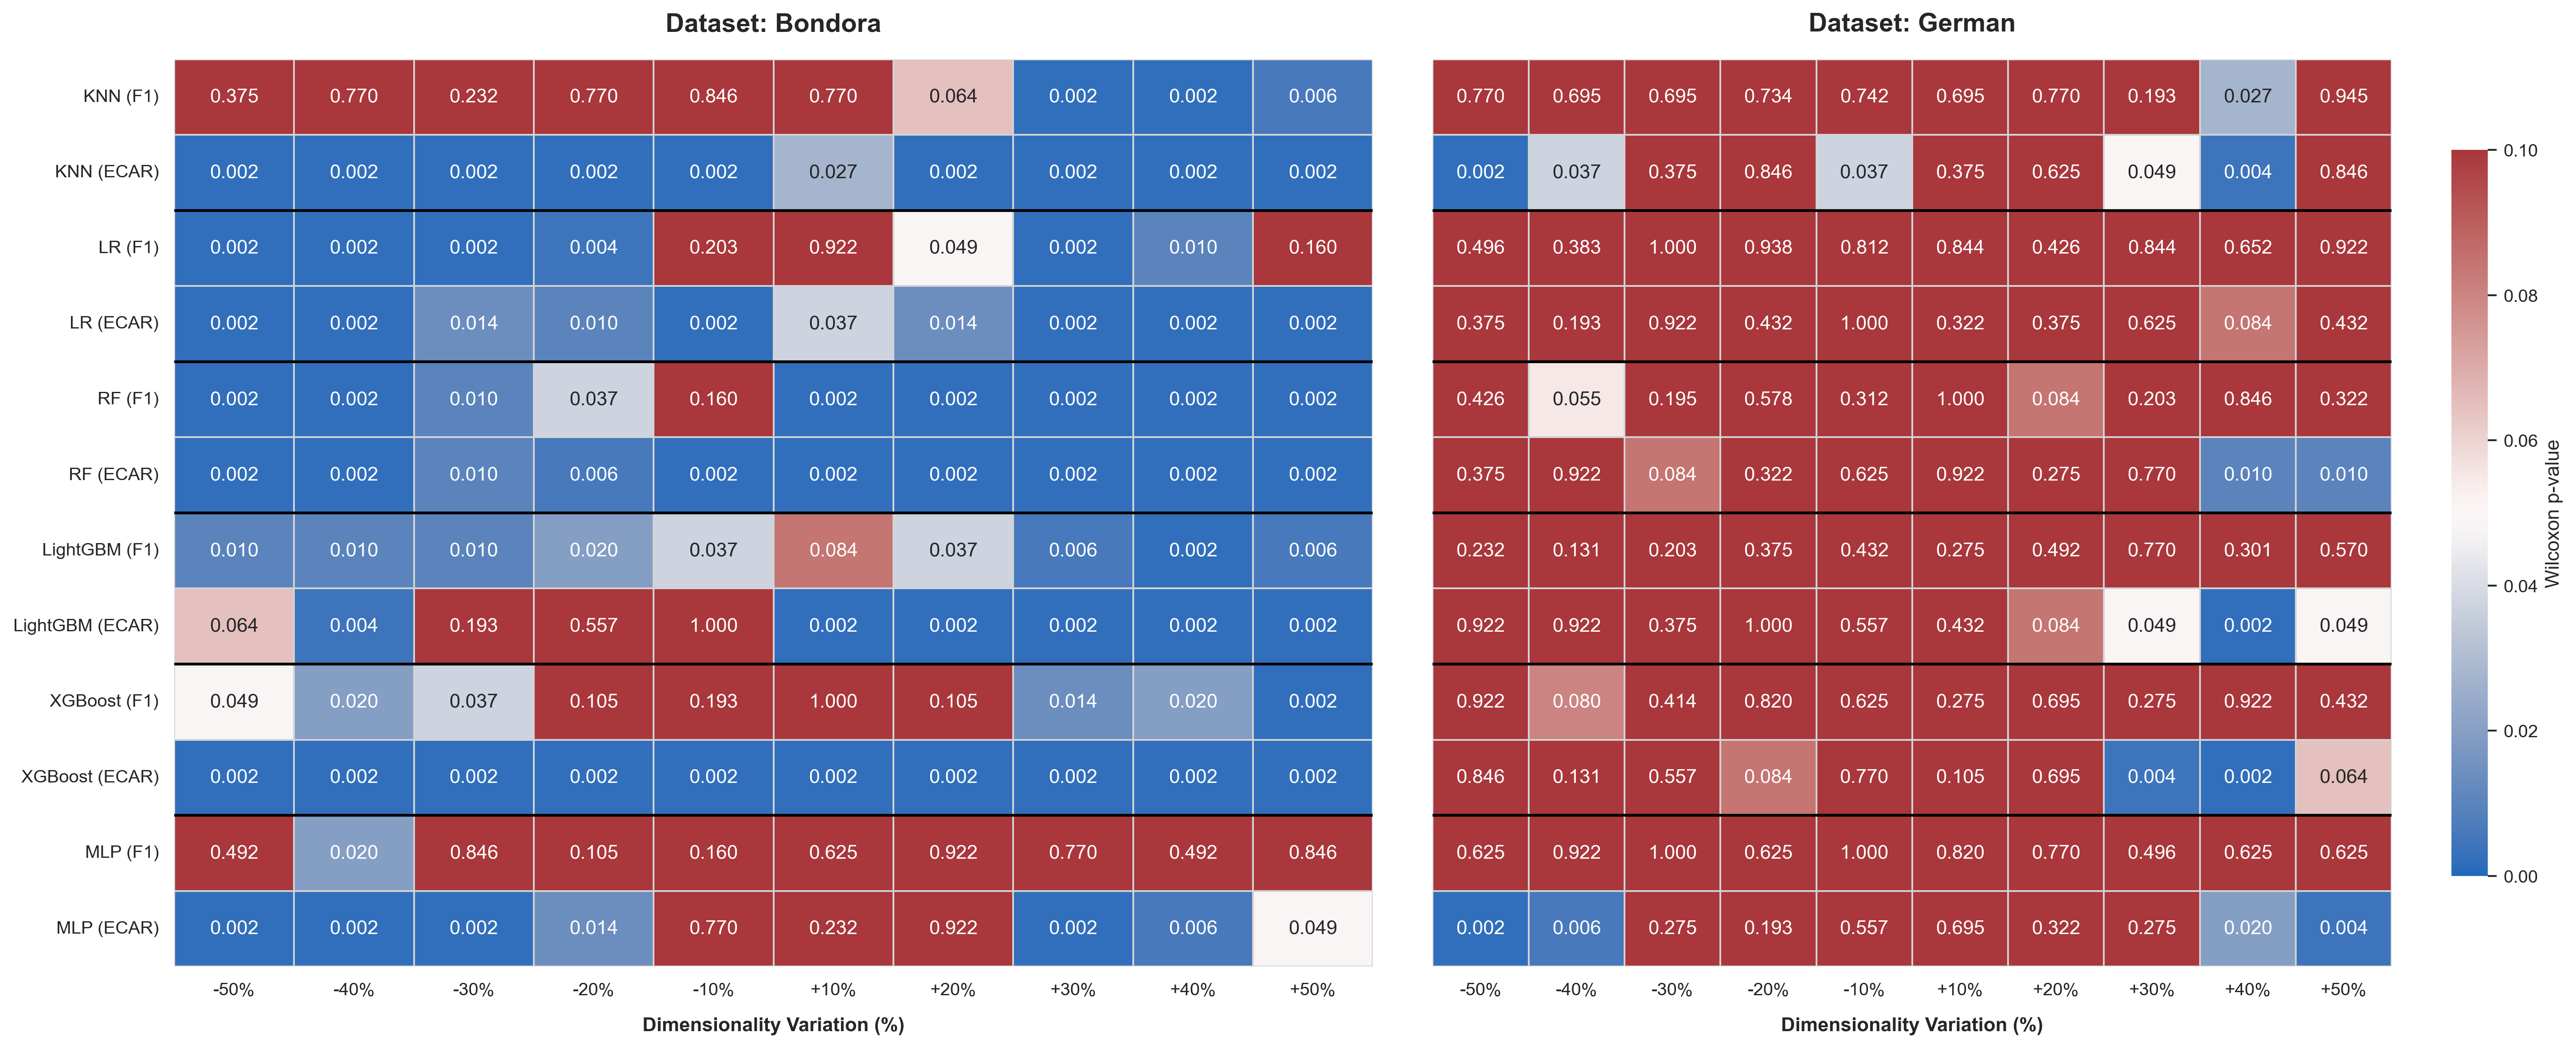

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import numpy as np
import os

sns.set_theme(style="white", context="paper", font_scale=1.1)

bases = ['Bondora', 'German']
modelos = ['KNN', 'LR', 'RF', 'LightGBM', 'XGBoost', 'MLP']

cenarios_labels = ['-50%', '-40%', '-30%', '-20%', '-10%', '+10%', '+20%', '+30%', '+40%', '+50%']
cenarios_paths = [
    ('REDUCAO', 50), ('REDUCAO', 40), ('REDUCAO', 30), ('REDUCAO', 20), ('REDUCAO', 10),
    ('AUMENTO', 10), ('AUMENTO', 20), ('AUMENTO', 30), ('AUMENTO', 40), ('AUMENTO', 50)
]

def calc_ecar_fold(df_mod):
    return ((df_mod['energia_kwh'] + df_mod['energia_grid_total_kwh']) * 46.1) / df_mod['f1']

# --- CRIANDO A FIGURA ÚNICA COM 2 LADOS ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=300)

for idx_base, base in enumerate(bases):
    path_base = f'../reports/resultados/{base}/[REDUCAO 0% - CC]-{base}.csv'
    if not os.path.exists(path_base):
        continue
    df_base = pd.read_csv(path_base, sep=';')
    
    p_values_matrix = np.zeros((len(modelos) * 2, len(cenarios_paths)))
    row_labels = []
    
    for i, modelo in enumerate(modelos):
        df_b_mod = df_base[df_base['modelo'] == modelo]
        folds_b_f1 = df_b_mod['f1'].values
        folds_b_ecar = calc_ecar_fold(df_b_mod).values
        
        row_labels.append(f"{modelo} (F1)")
        row_labels.append(f"{modelo} (ECAR)")
        
        for j, (tipo, pct) in enumerate(cenarios_paths):
            path_cenario = f'../reports/resultados/{base}/[{tipo} {pct}% - CC]-{base}.csv'
            if os.path.exists(path_cenario):
                df_cenario = pd.read_csv(path_cenario, sep=';')
                df_c_mod = df_cenario[df_cenario['modelo'] == modelo]
                
                folds_c_f1 = df_c_mod['f1'].values
                folds_c_ecar = calc_ecar_fold(df_c_mod).values
                
                # F1 vai na linha par (0, 2, 4...)
                try:
                    _, p_val = wilcoxon(folds_b_f1, folds_c_f1)
                    p_values_matrix[2*i, j] = p_val
                except ValueError:
                    p_values_matrix[2*i, j] = 1.0 
                    
                # ECAR vai na linha ímpar (1, 3, 5...)
                try:
                    _, p_val = wilcoxon(folds_b_ecar, folds_c_ecar)
                    p_values_matrix[2*i+1, j] = p_val
                except ValueError:
                    p_values_matrix[2*i+1, j] = 1.0 
            else:
                p_values_matrix[2*i, j] = np.nan
                p_values_matrix[2*i+1, j] = np.nan

    df_p = pd.DataFrame(p_values_matrix, index=row_labels, columns=cenarios_labels)

    ax = axes[idx_base]
    
    # Apenas mostrar a barra de cor no gráfico da direita para não ficar repetitivo
    show_cbar = True if idx_base == 1 else False
    
    sns.heatmap(df_p, ax=ax, annot=True, fmt=".3f", cmap="vlag", 
                vmin=0, vmax=0.1, center=0.05, 
                cbar=show_cbar,
                cbar_kws={'label': 'Wilcoxon p-value', 'shrink': 0.8} if show_cbar else None, 
                linewidths=0.5, linecolor='lightgray')
    
    # Linhas pretas horizontais para separar por modelo
    for i in range(2, len(modelos)*2, 2):
        ax.axhline(i, color='black', lw=1.5)
        
    ax.set_title(f'Dataset: {base}', fontweight='bold', pad=15, fontsize=14)
    ax.set_xlabel('Dimensionality Variation (%)', fontweight='bold', labelpad=10)
    
    # Configurando o Eixo Y para que apenas o gráfico da esquerda tenha os nomes
    if idx_base == 0:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    else:
        ax.set_yticks([]) # Oculta os nomes dos modelos no gráfico da direita

# Ajuste fino para os dois gráficos ficarem perto um do outro
plt.tight_layout()
plt.subplots_adjust(wspace=0.05) # Diminui o espaço em branco entre eles

caminho_salvar = '../reports/graficos/heatmap_wilcoxon_ambos.pdf'
plt.savefig(caminho_salvar, format='pdf', bbox_inches='tight')
print(f"Heatmap completo gerado em: {caminho_salvar}")
